# Tier 2 prediction analysis

Load one Tier 2 main-cell CSV and its automatically matched moderator-cell CSV. Tier 2 data contain predicted means only, so no variance or uncertainty estimates are calculated.

In [12]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', context='notebook')

OUTCOMES = [
    'trust_multidimensional', 'trust_post', 'distrust_post',
    'funding_perceptions', 'policy_role_mean', 'inst_trust_mean',
    'belief_post', 'concern_mean', 'policy_general',
    'policy_specific_mean', 'behavior_mean', 'donation_ams',
    'newsletter_signup',
]
MODERATORS = {
    'gender': ['Male', 'Female', 'Other'],
    'age_band': ['18-29', '30-44', '45-59', '60+'],
    'race': ['White / Caucasian', 'Black / African American', 'Hispanic / Latino', 'Asian / Asian American', 'Other'],
    'education': ['Less than high school', 'High school diploma / GED', 'Some college or Associate\'s degree', 'Bachelor\'s degree', 'Master\'s degree / Professional degree', 'Doctorate degree / Ph.D.'],
    'income': ['Less than $30,000', '$30,000 to $55,999', '$56,000 to $99,999', '$100,000 to $167,999', '$168,000 or more'],
    'party': ['Republican', 'Democrat', 'Independent', 'Other'],
}

def find_repository_root():
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'predictions').exists():
            return candidate
    raise RuntimeError('Could not find the repository root. Run the notebook from this repository or a child directory.')

REPO_ROOT = find_repository_root()
REPO_ROOT

PosixPath('/mnt/homes/maxi/2026/silicon_sampling_benchmark')

## Configuration

Change `PREDICTION_FILE` to the Tier 2 main-cell CSV you want to analyze. The matching moderator-cell CSV is found automatically.

In [13]:
PREDICTION_FILE = REPO_ROOT / 'predictions' / 'Qwen_Qwen3.6-27B_T2_primary_main.csv'
PREDICTION_FILE

PosixPath('/mnt/homes/maxi/2026/silicon_sampling_benchmark/predictions/Qwen_Qwen3.6-27B_T2_primary_main.csv')

In [14]:
def validate_numeric_mean(data, label):
    numeric = pd.to_numeric(data['mean'], errors='coerce')
    invalid = data['mean'].notna() & numeric.isna()
    if invalid.any():
        raise ValueError(f'{label} has {invalid.sum()} non-numeric mean value(s).')
    if numeric.isna().any():
        raise ValueError(f'{label} has {numeric.isna().sum()} missing mean value(s).')
    data['mean'] = numeric

def validate_t2_main(data):
    required = {'condition', 'outcome', 'mean'}
    missing = sorted(required.difference(data.columns))
    if missing:
        raise ValueError(f'Tier 2 main file is missing required columns: {missing}')
    invalid_outcomes = sorted(set(data['outcome']) - set(OUTCOMES))
    absent_outcomes = sorted(set(OUTCOMES) - set(data['outcome']))
    if invalid_outcomes or absent_outcomes:
        raise ValueError(f'Unexpected outcomes: {invalid_outcomes}; missing outcomes: {absent_outcomes}')
    if data.duplicated(['condition', 'outcome']).any():
        raise ValueError('Tier 2 main file has duplicate condition/outcome cells.')
    validate_numeric_mean(data, 'Tier 2 main file')

def validate_t2_moderator(data, conditions):
    required = {'condition', 'moderator', 'moderator_level', 'outcome', 'mean'}
    missing = sorted(required.difference(data.columns))
    if missing:
        raise ValueError(f'Tier 2 moderator file is missing required columns: {missing}')
    if set(data['moderator']) != set(MODERATORS):
        raise ValueError('Tier 2 moderator file must contain exactly the six benchmark demographic attributes.')
    invalid_outcomes = sorted(set(data['outcome']) - set(OUTCOMES))
    absent_outcomes = sorted(set(OUTCOMES) - set(data['outcome']))
    if invalid_outcomes or absent_outcomes:
        raise ValueError(f'Unexpected outcomes: {invalid_outcomes}; missing outcomes: {absent_outcomes}')
    invalid_levels = data.apply(lambda row: row['moderator_level'] not in MODERATORS.get(row['moderator'], []), axis=1)
    if invalid_levels.any():
        raise ValueError(f'Tier 2 moderator file has {invalid_levels.sum()} invalid moderator-level pair(s).')
    if data.duplicated(['condition', 'moderator', 'moderator_level', 'outcome']).any():
        raise ValueError('Tier 2 moderator file has duplicate cells.')
    validate_numeric_mean(data, 'Tier 2 moderator file')

def load_t2_predictions(main_path):
    main_path = Path(main_path)
    if not main_path.is_file():
        raise FileNotFoundError(f'Tier 2 main prediction file not found: {main_path}')
    if '_T2_' not in main_path.name:
        raise ValueError(f'Expected a Tier 2 file name containing _T2_, got: {main_path.name}')
    if main_path.name.endswith('_cells_main.csv'):
        moderator_name = main_path.name.replace('_cells_main.csv', '_cells_moderator.csv')
    elif main_path.name.endswith('_main.csv'):
        moderator_name = main_path.name.replace('_main.csv', '_moderator.csv')
    else:
        raise ValueError(f'Expected a Tier 2 main file ending in _cells_main.csv or _main.csv, got: {main_path.name}')
    moderator_path = main_path.with_name(moderator_name)
    if not moderator_path.is_file():
        raise FileNotFoundError(f'Matching Tier 2 moderator file not found: {moderator_path}')

    main = pd.read_csv(main_path)
    moderator = pd.read_csv(moderator_path)
    validate_t2_main(main)
    condition_order = ['control', *sorted(value for value in main['condition'].dropna().unique() if value != 'control')]
    validate_t2_moderator(moderator, set(condition_order))
    if set(moderator['condition']) != set(condition_order):
        raise ValueError('Tier 2 main and moderator files do not contain the same conditions.')

    main['condition'] = pd.Categorical(main['condition'], categories=condition_order, ordered=True)
    moderator['condition'] = pd.Categorical(moderator['condition'], categories=condition_order, ordered=True)
    return main, moderator, condition_order, moderator_path

main, moderator, CONDITION_ORDER, MODERATOR_FILE = load_t2_predictions(PREDICTION_FILE)
print(f'Loaded {PREDICTION_FILE.name} and {MODERATOR_FILE.name}.')

Loaded Qwen_Qwen3.6-27B_T2_primary_main.csv and Qwen_Qwen3.6-27B_T2_primary_moderator.csv.


In [15]:
condition_means_table = (
    main.pivot(index='condition', columns='outcome', values='mean')
    .reindex(index=CONDITION_ORDER, columns=OUTCOMES)
    .rename_axis(index='condition', columns=None)
)
print('Condition means')
display(condition_means_table.style.format('{:,.3f}'))

Condition means


,trust_multidimensional,trust_post,distrust_post,funding_perceptions,policy_role_mean,inst_trust_mean,belief_post,concern_mean,policy_general,policy_specific_mean,behavior_mean,donation_ams,newsletter_signup
condition,,,,,,,,,,,,,
control,70.344,71.648,26.674,60.926,68.606,64.881,77.696,69.617,71.526,70.239,45.447,3.059,1.470
Consensus,70.021,69.837,29.989,56.222,65.908,63.229,78.026,69.064,68.756,69.017,44.637,3.071,1.408
Corporate reliance,71.685,73.738,25.620,60.227,68.652,65.237,80.915,71.241,72.173,69.774,45.048,3.475,1.411
Extreme weather predictions,71.152,72.700,26.374,60.481,67.669,64.659,78.770,71.272,71.244,68.532,45.242,3.078,1.486
Former skeptics,73.686,76.485,22.570,61.189,69.654,66.456,83.163,73.042,72.926,70.011,47.581,3.753,2.647
Funding,68.451,69.296,28.181,61.559,64.491,61.753,75.130,67.580,68.815,66.872,44.022,3.127,1.503
High public trust,73.195,76.856,23.378,58.974,68.449,66.067,80.326,71.478,73.096,70.435,47.496,3.659,1.492
Interview Prof. Maraun,75.587,75.563,24.430,58.541,66.781,65.840,79.411,69.373,70.141,69.633,46.765,3.494,1.465
Interview Prof. Sebille,76.014,76.207,23.119,63.430,70.936,66.460,81.681,73.515,72.819,71.917,50.378,3.356,1.418


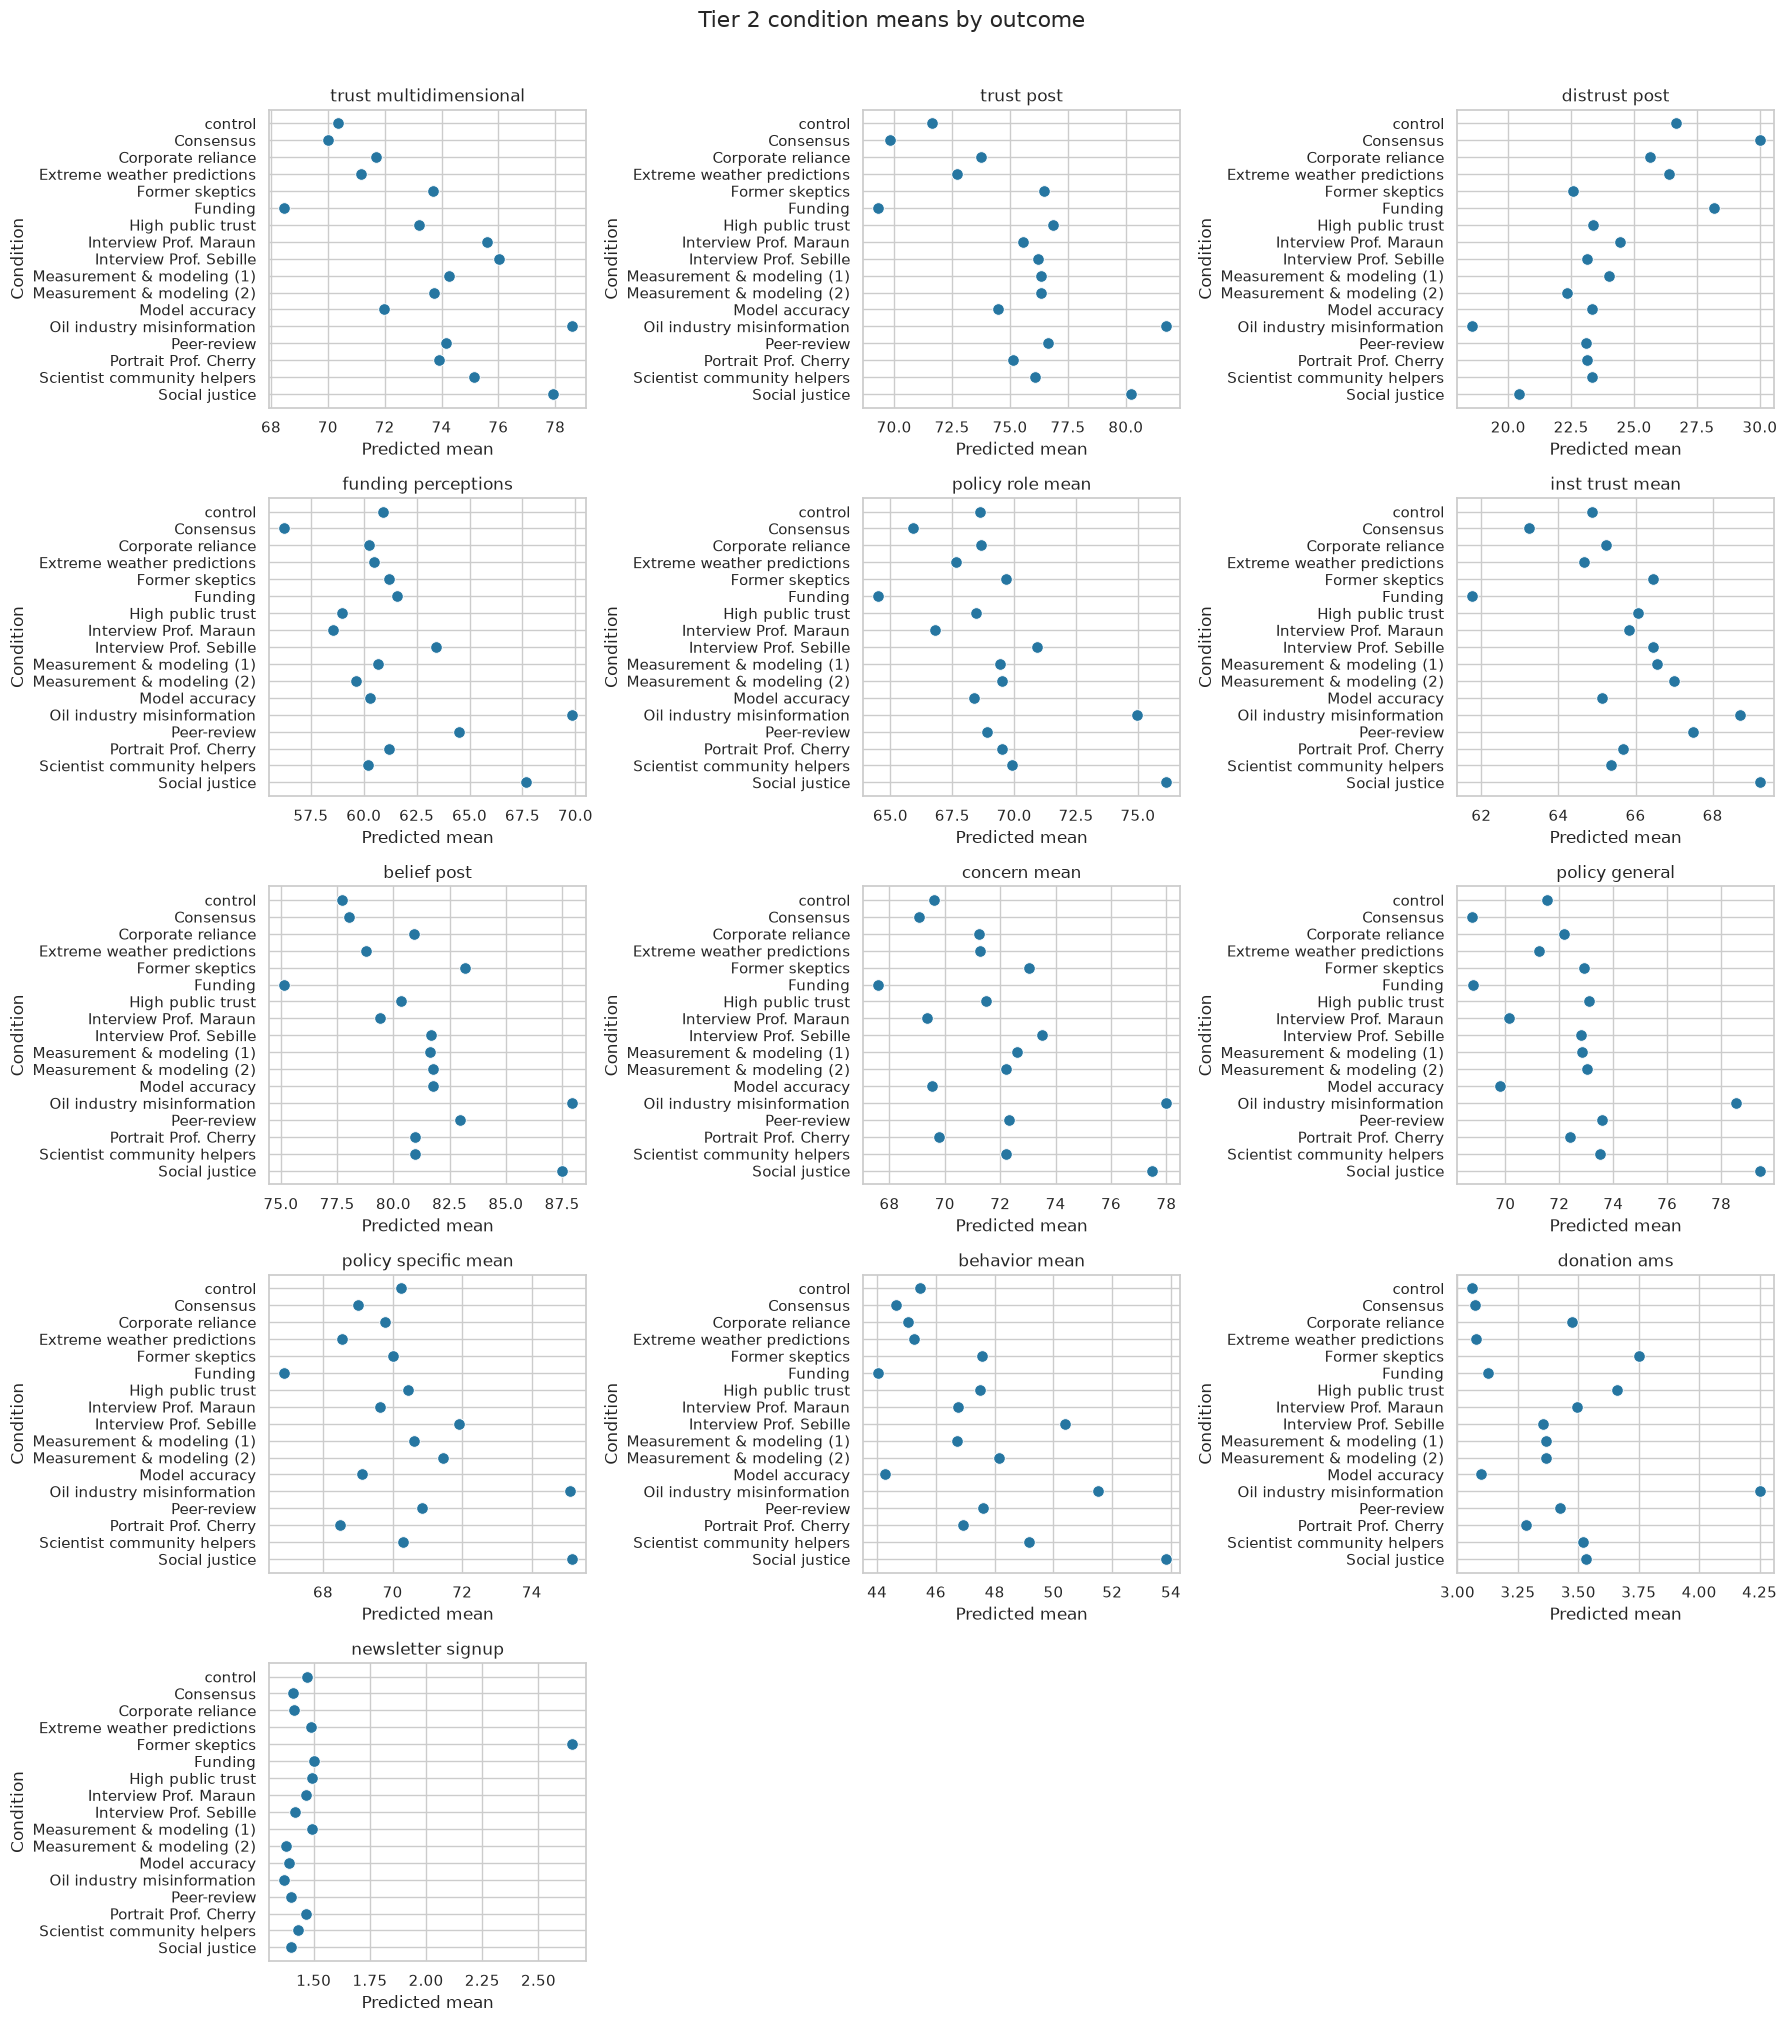

In [16]:
def outcome_label(outcome):
    return outcome.replace('_', ' ')

def plot_condition_means(data):
    columns = 3
    rows = math.ceil(len(OUTCOMES) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(18, 4 * rows), squeeze=False)
    for axis, outcome in zip(axes.flat, OUTCOMES):
        selected = data[data['outcome'] == outcome]
        sns.scatterplot(data=selected, x='mean', y='condition', s=70, color='#2676a1', ax=axis)
        axis.set_title(outcome_label(outcome))
        axis.set_xlabel('Predicted mean')
        axis.set_ylabel('Condition')
    for axis in axes.flat[len(OUTCOMES):]:
        axis.remove()
    fig.suptitle('Tier 2 condition means by outcome', y=1.01, fontsize=16)
    fig.tight_layout()
    plt.show()

plot_condition_means(main)

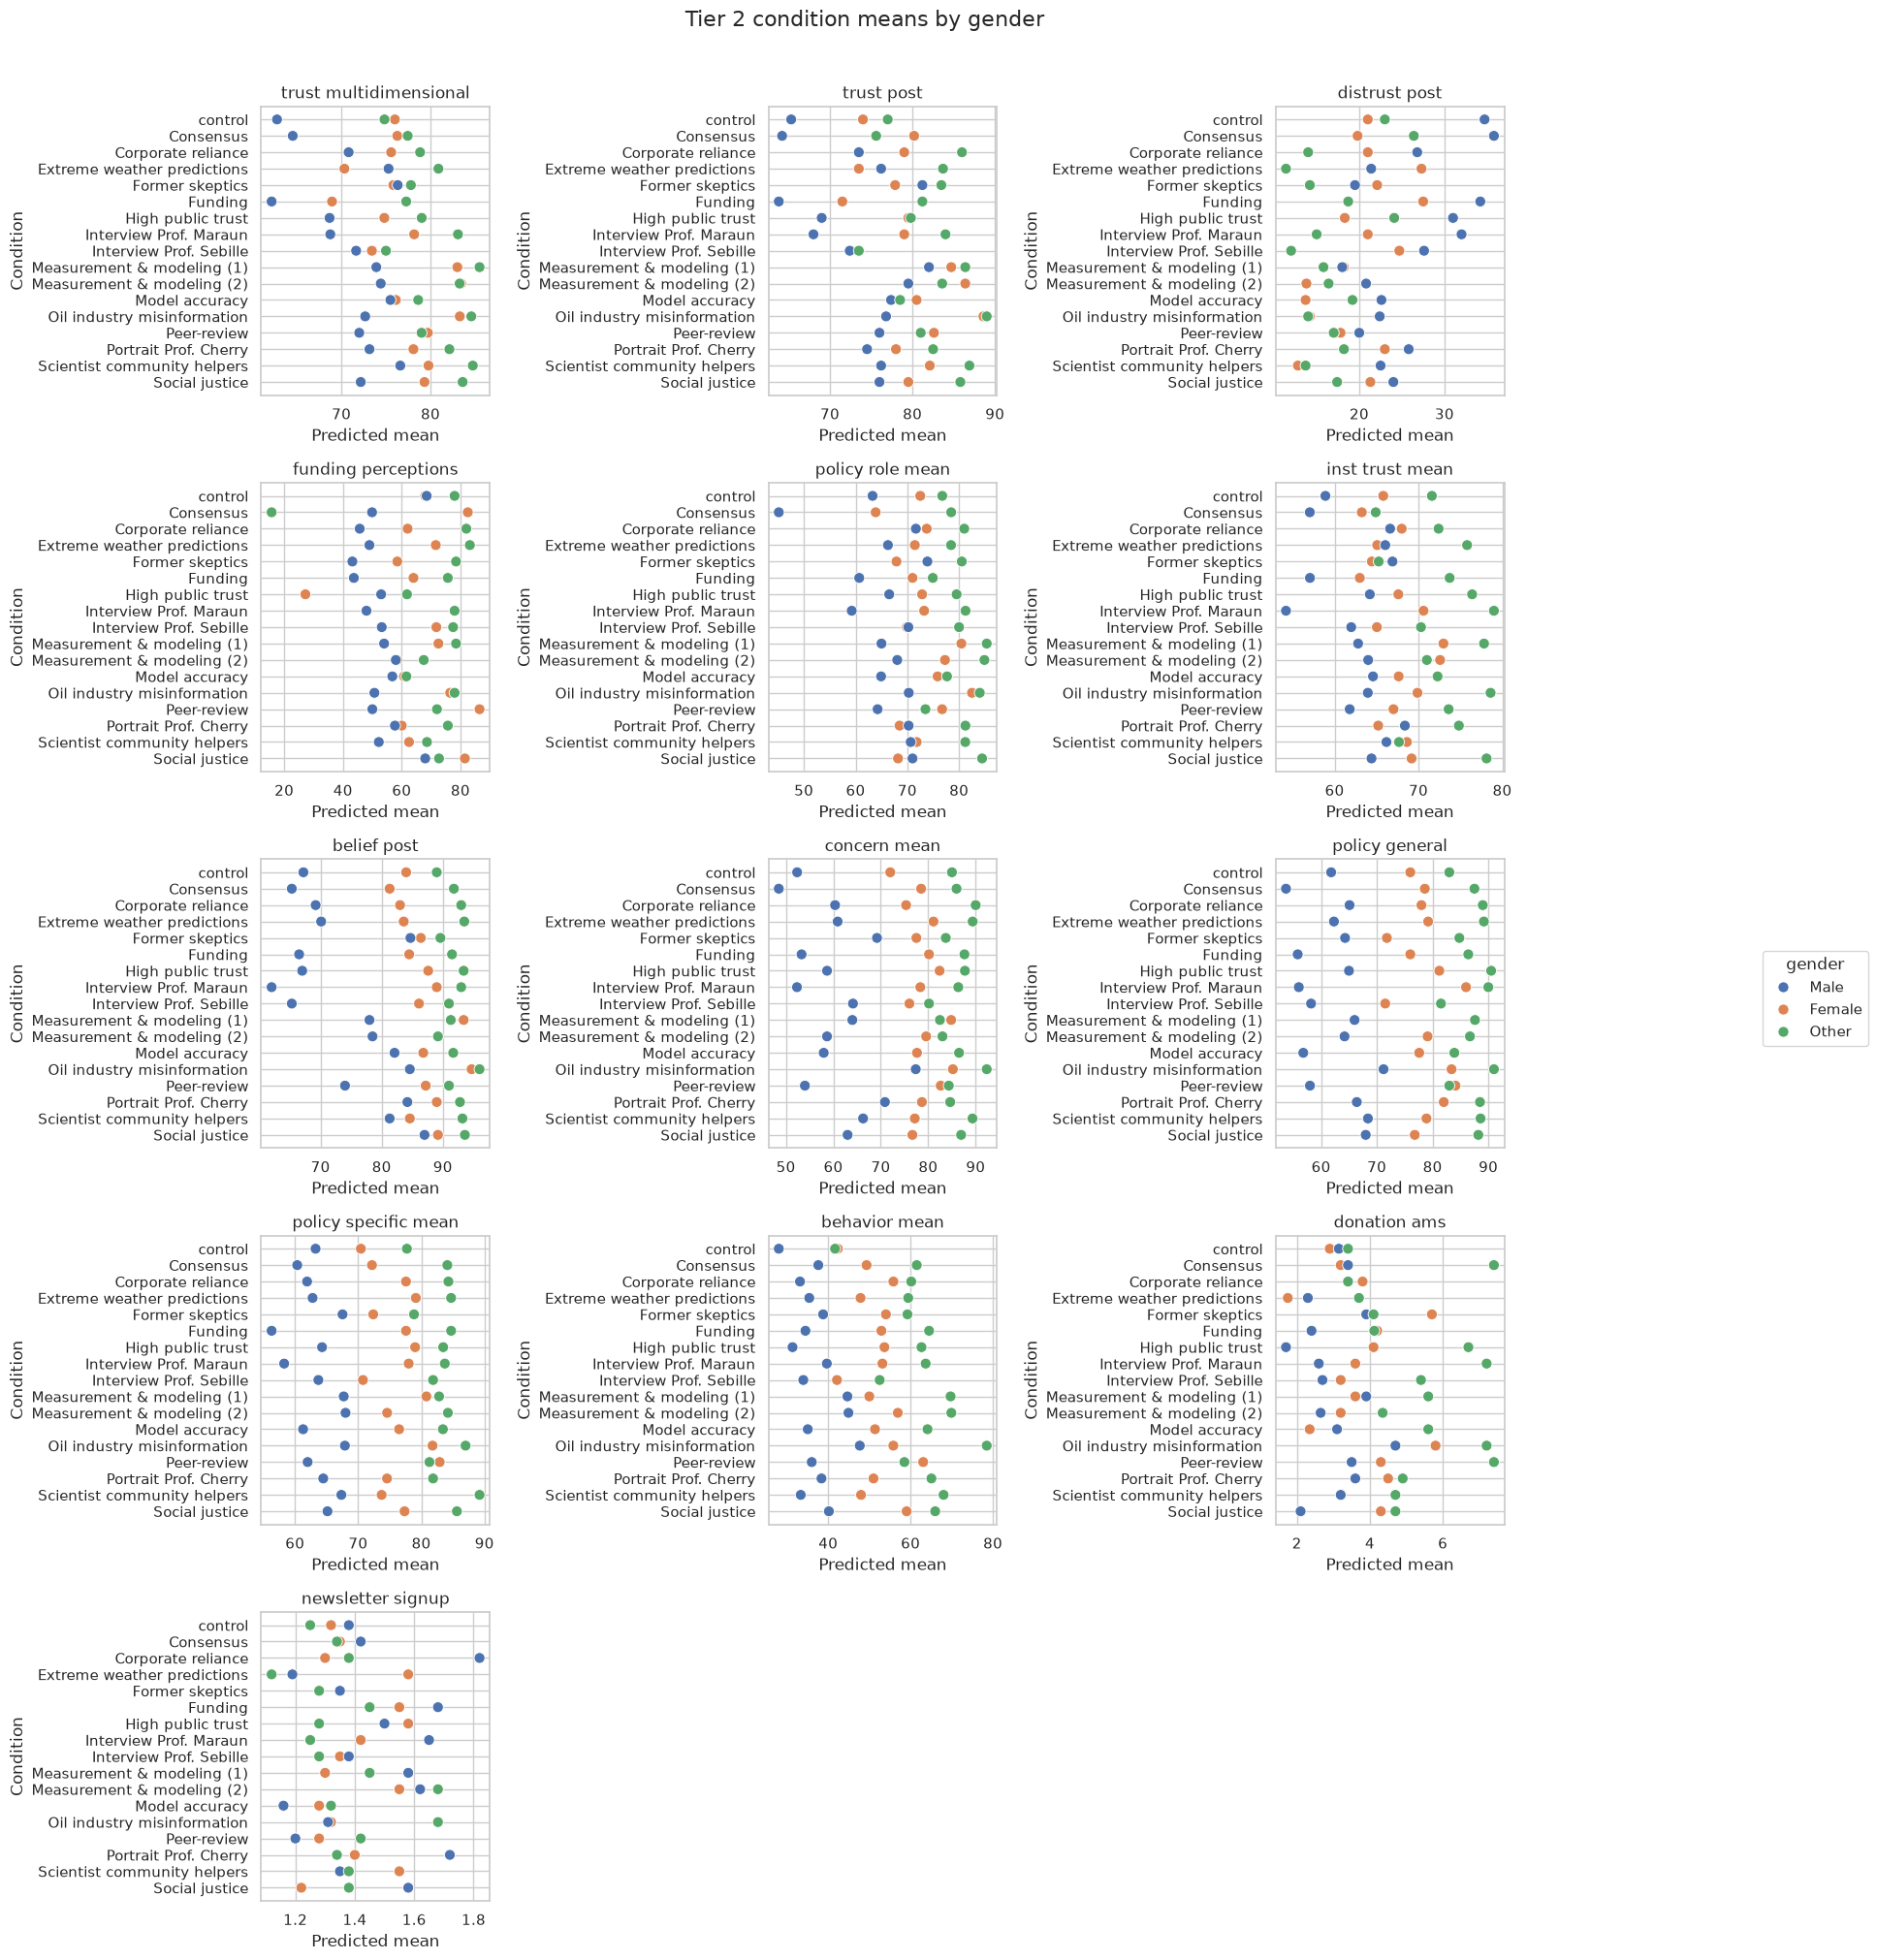

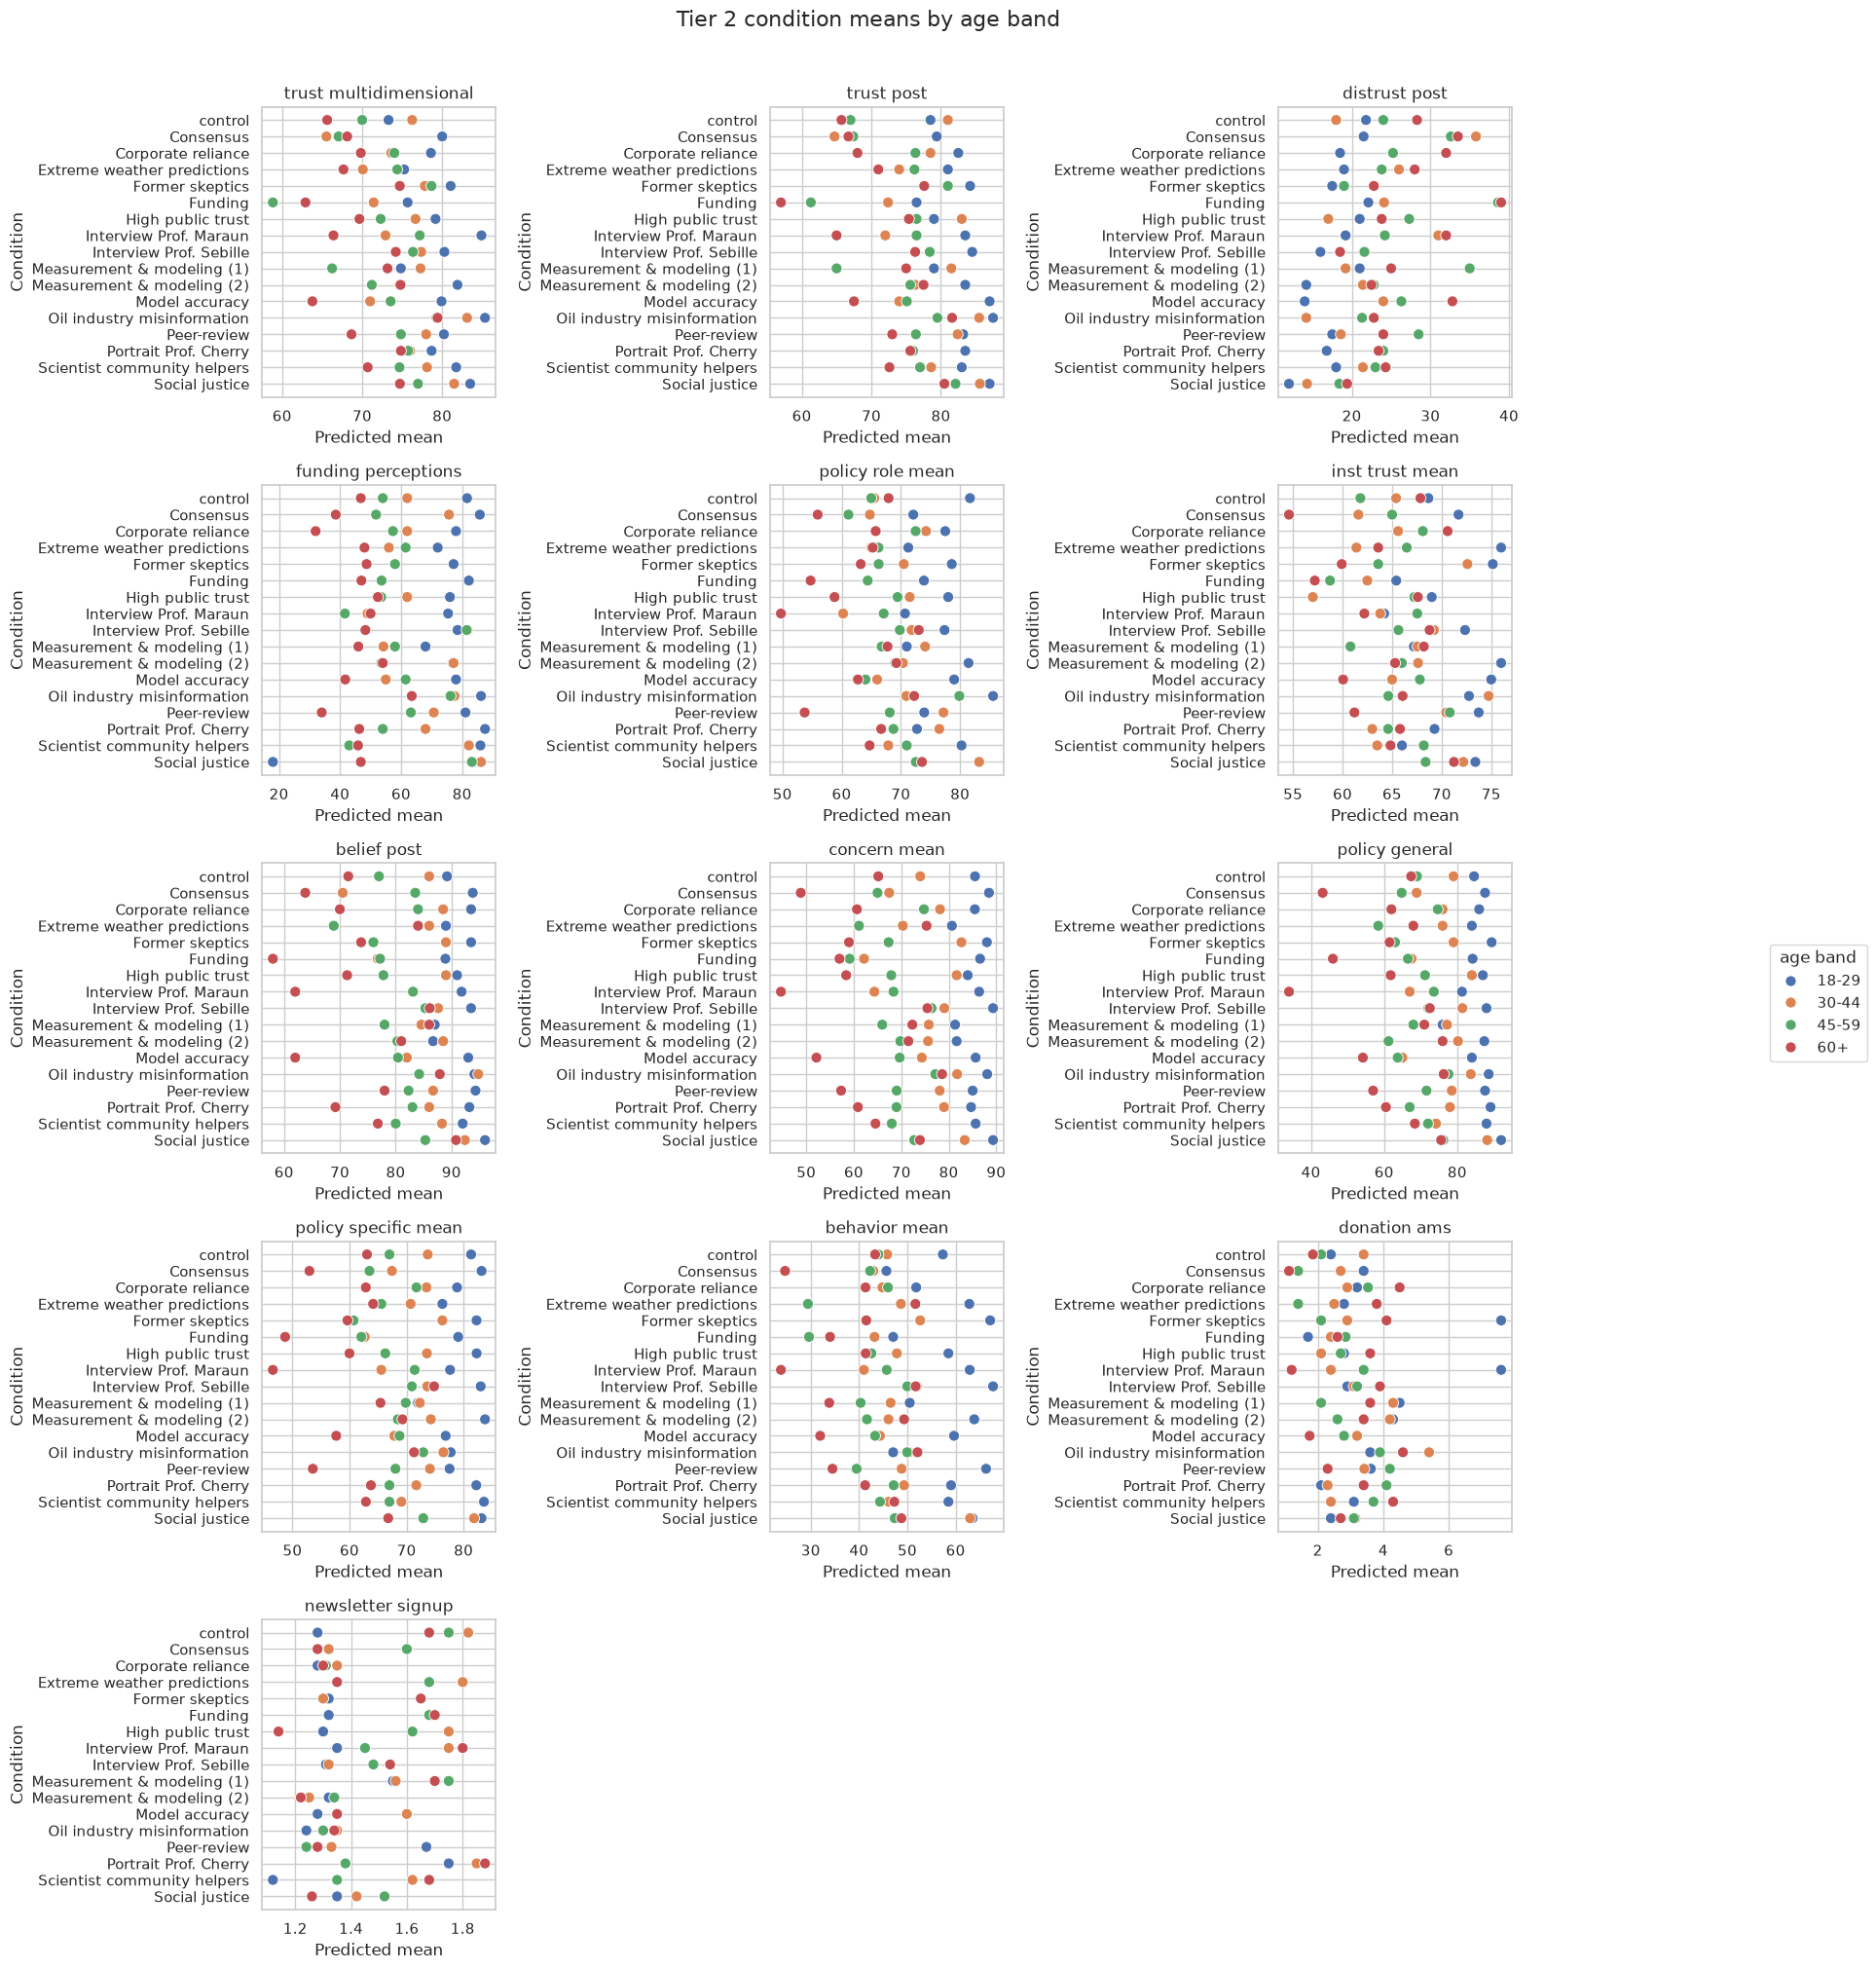

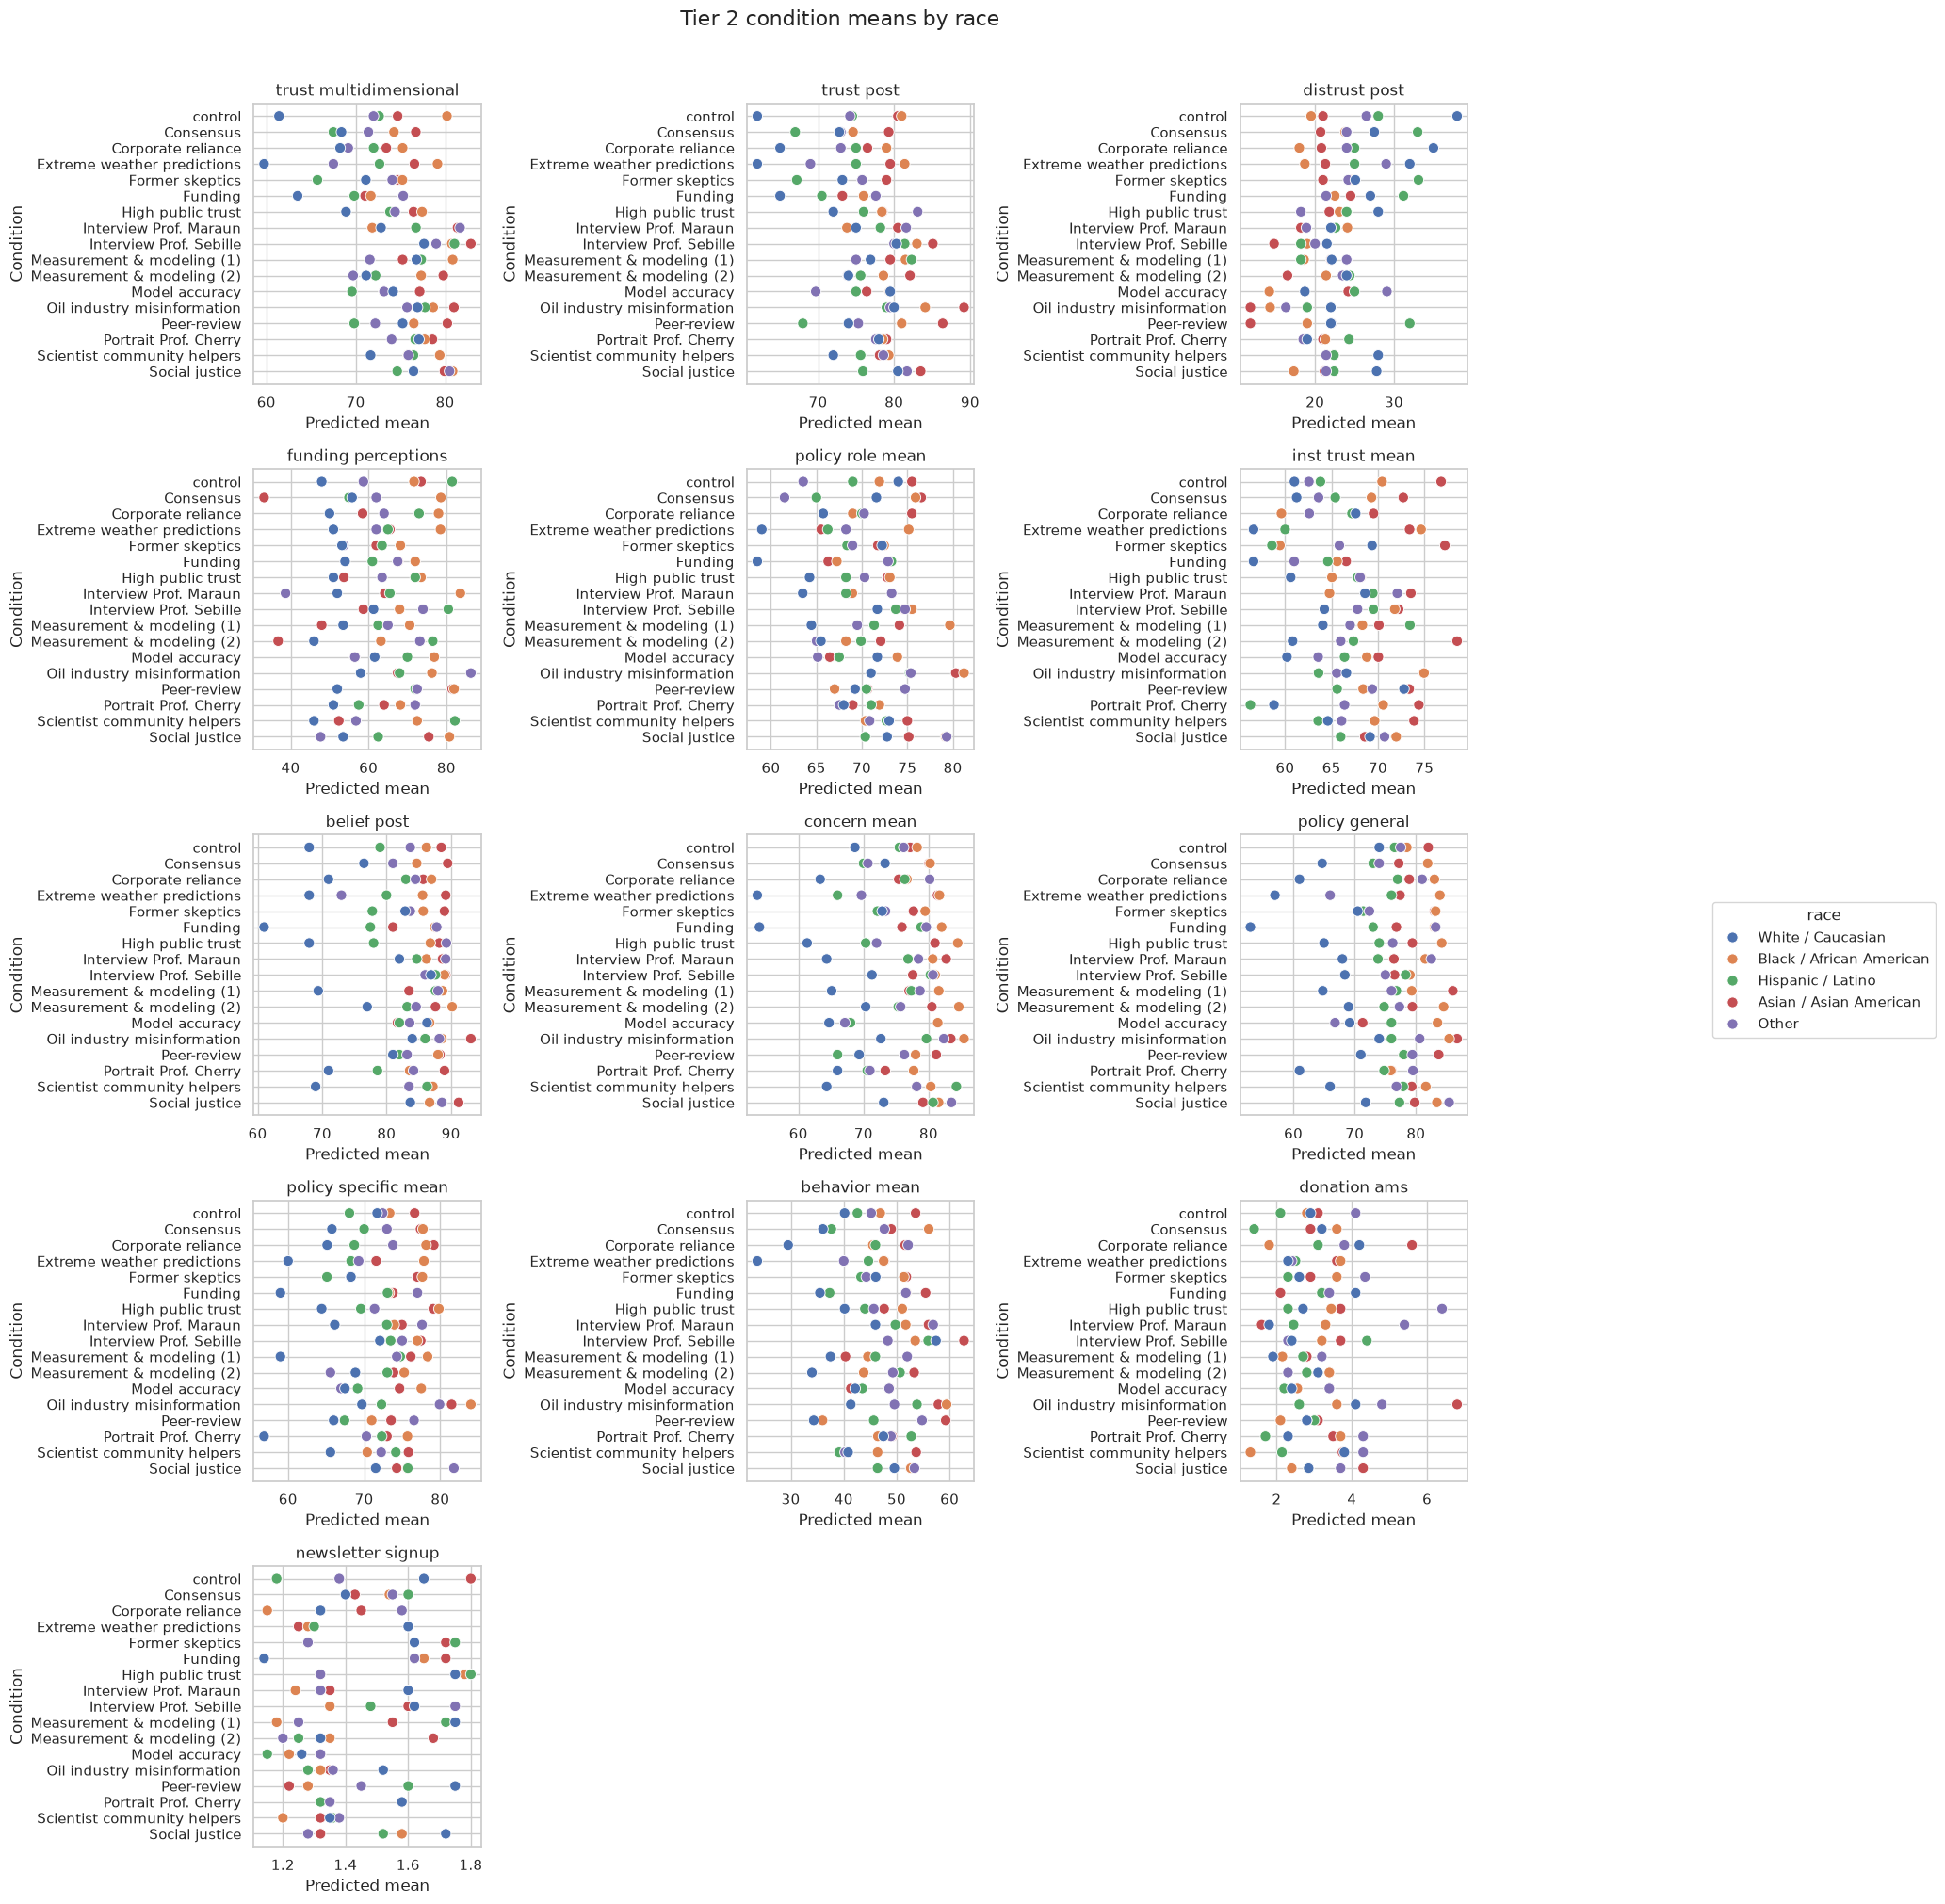

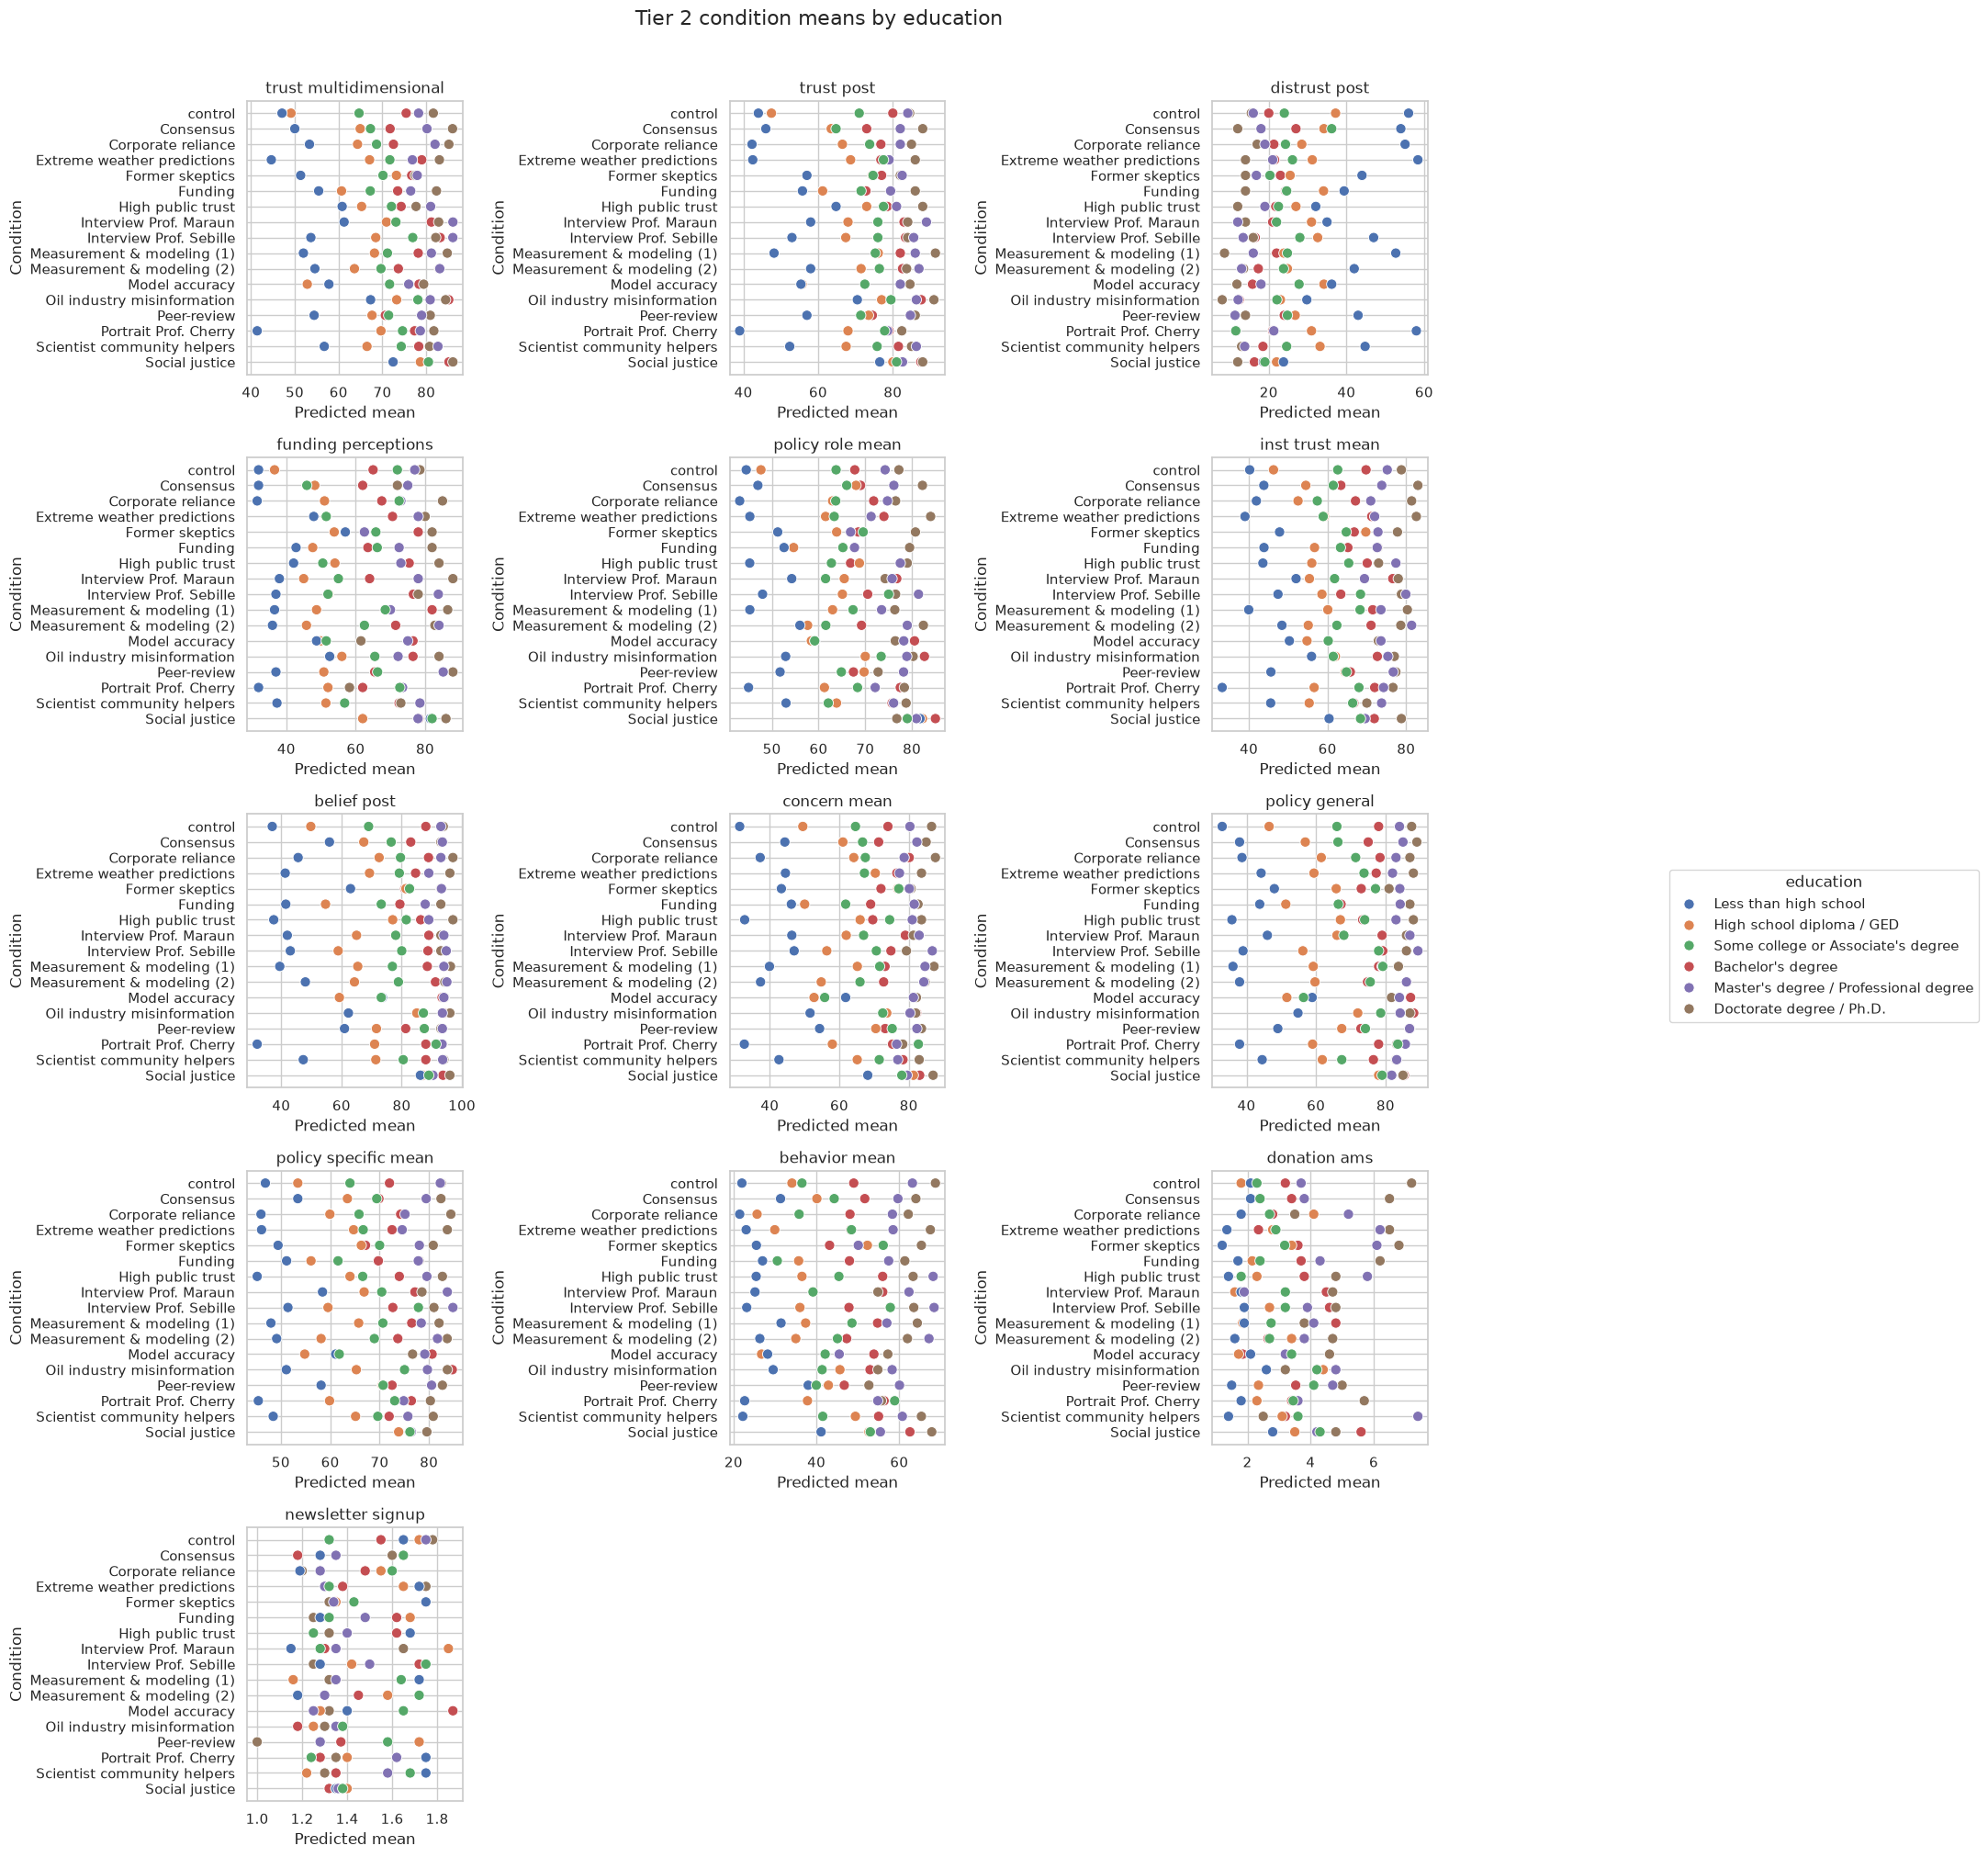

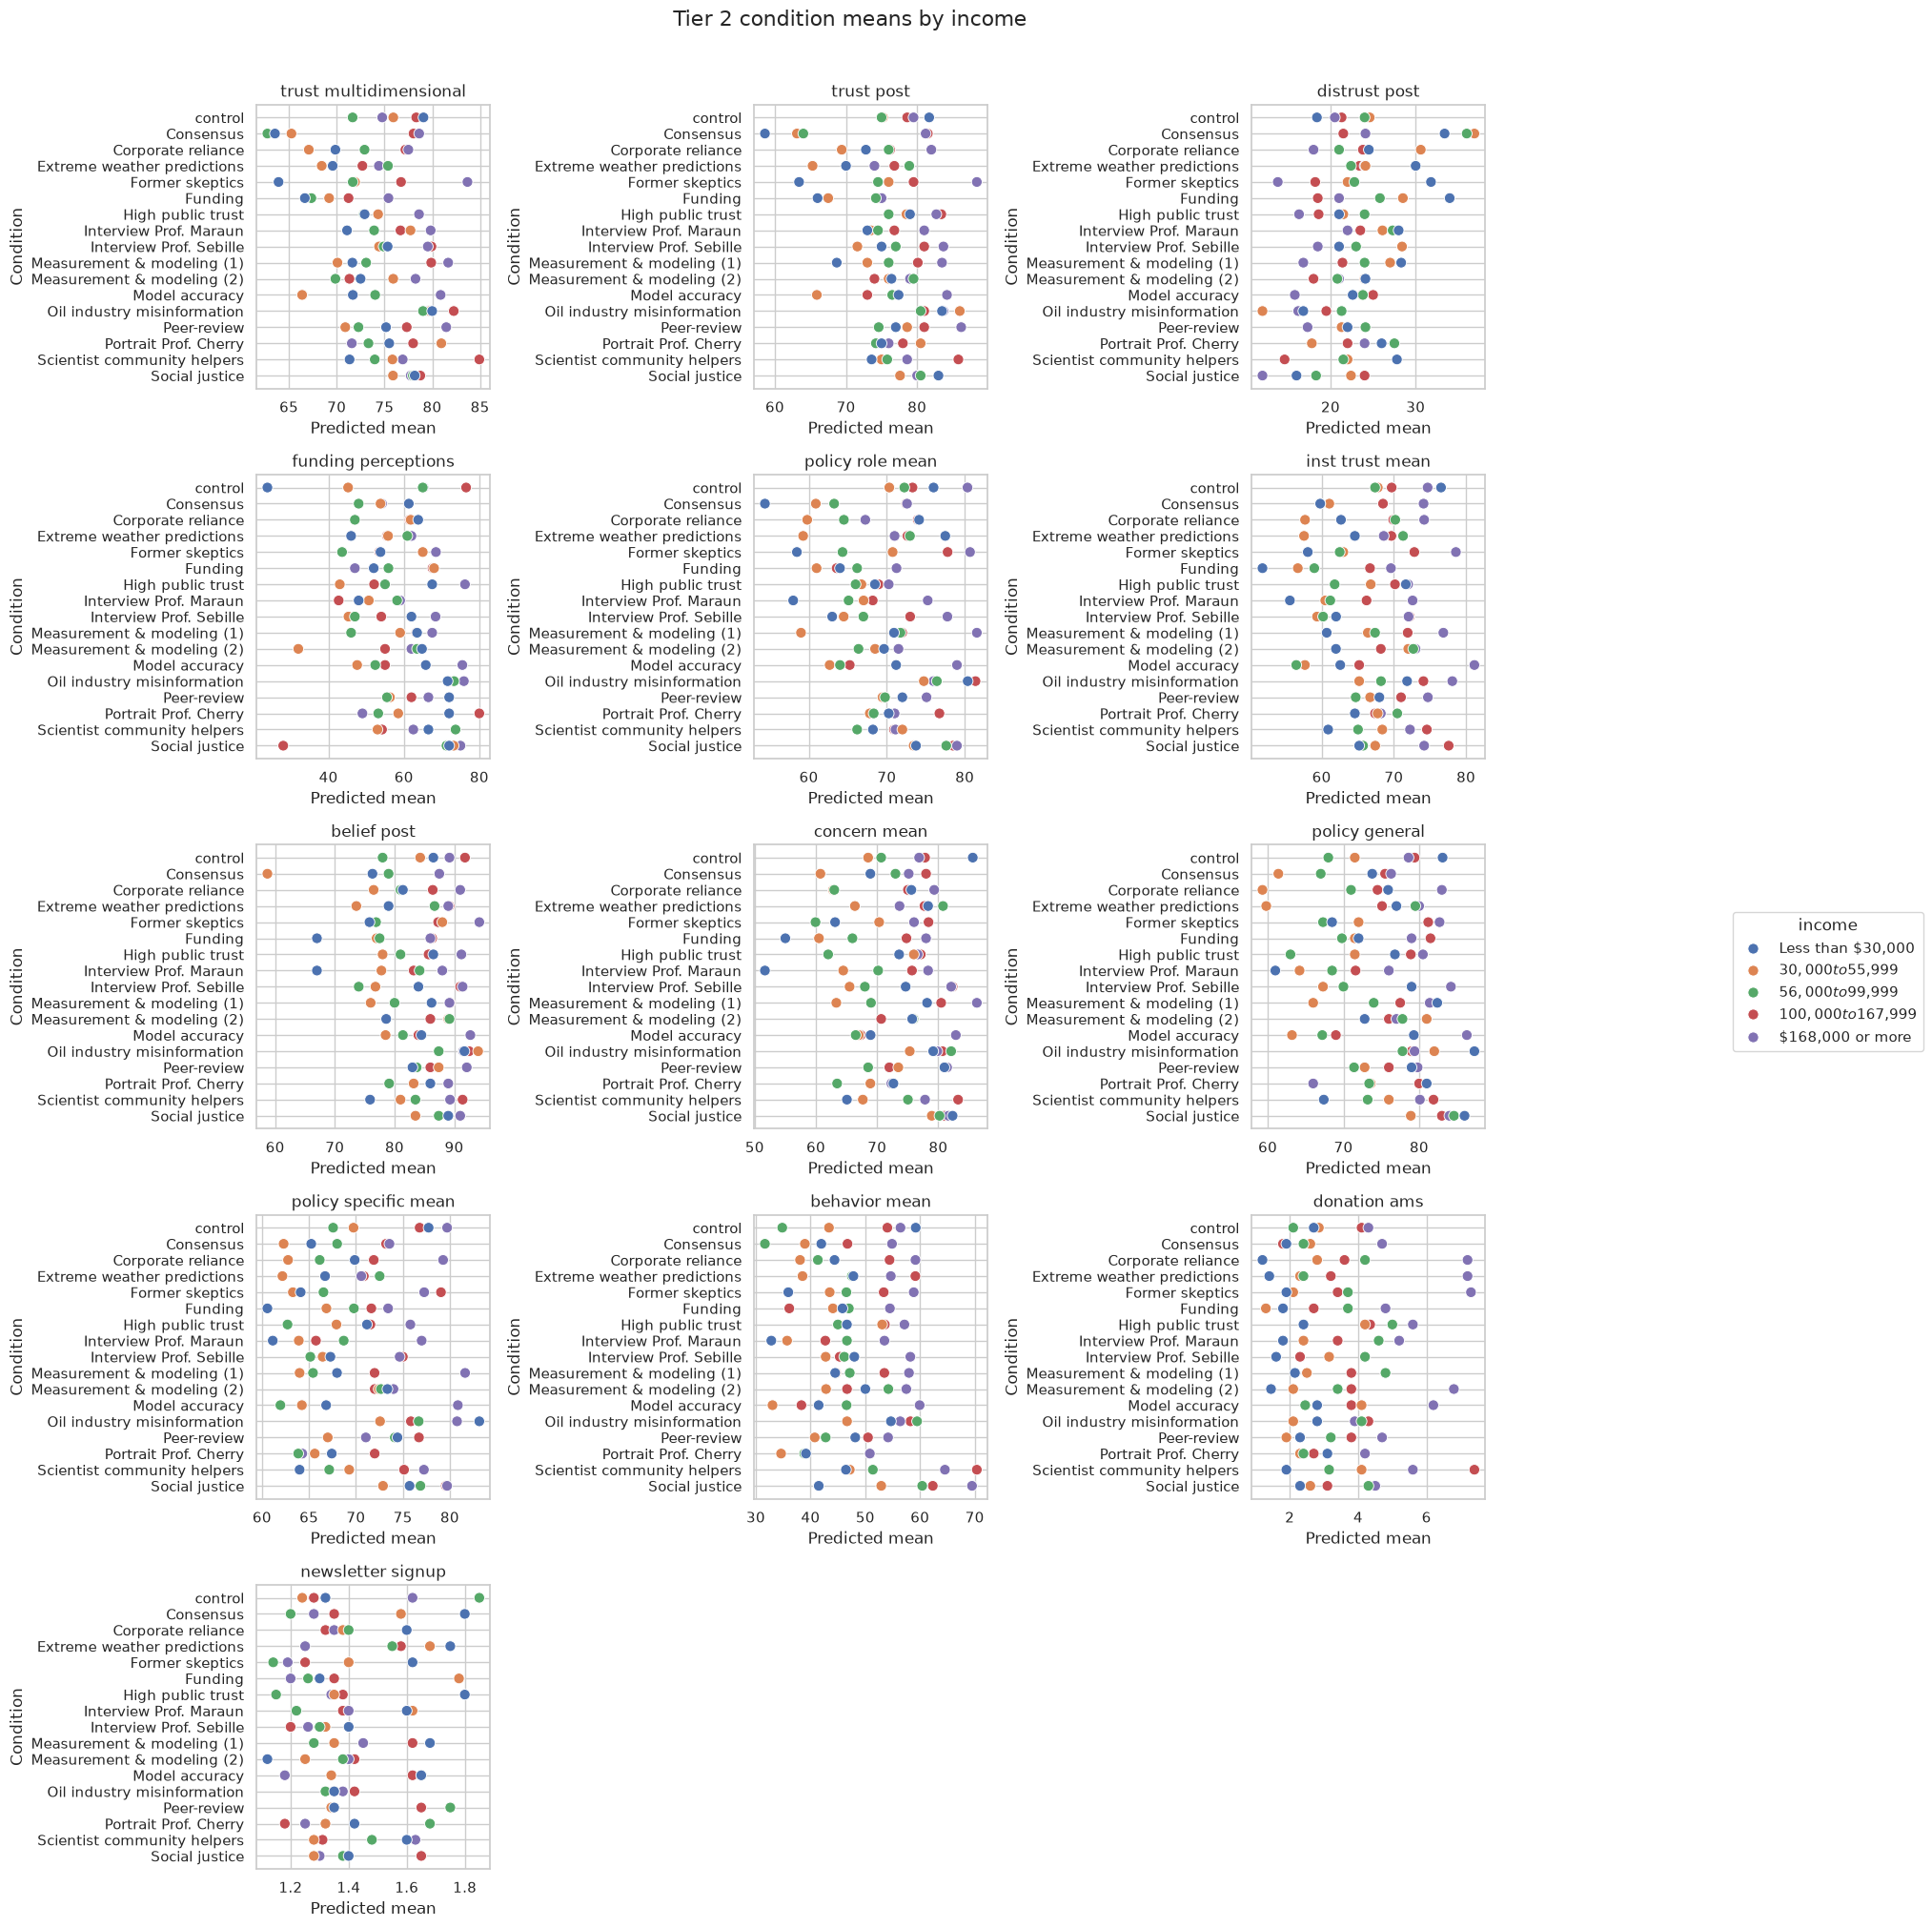

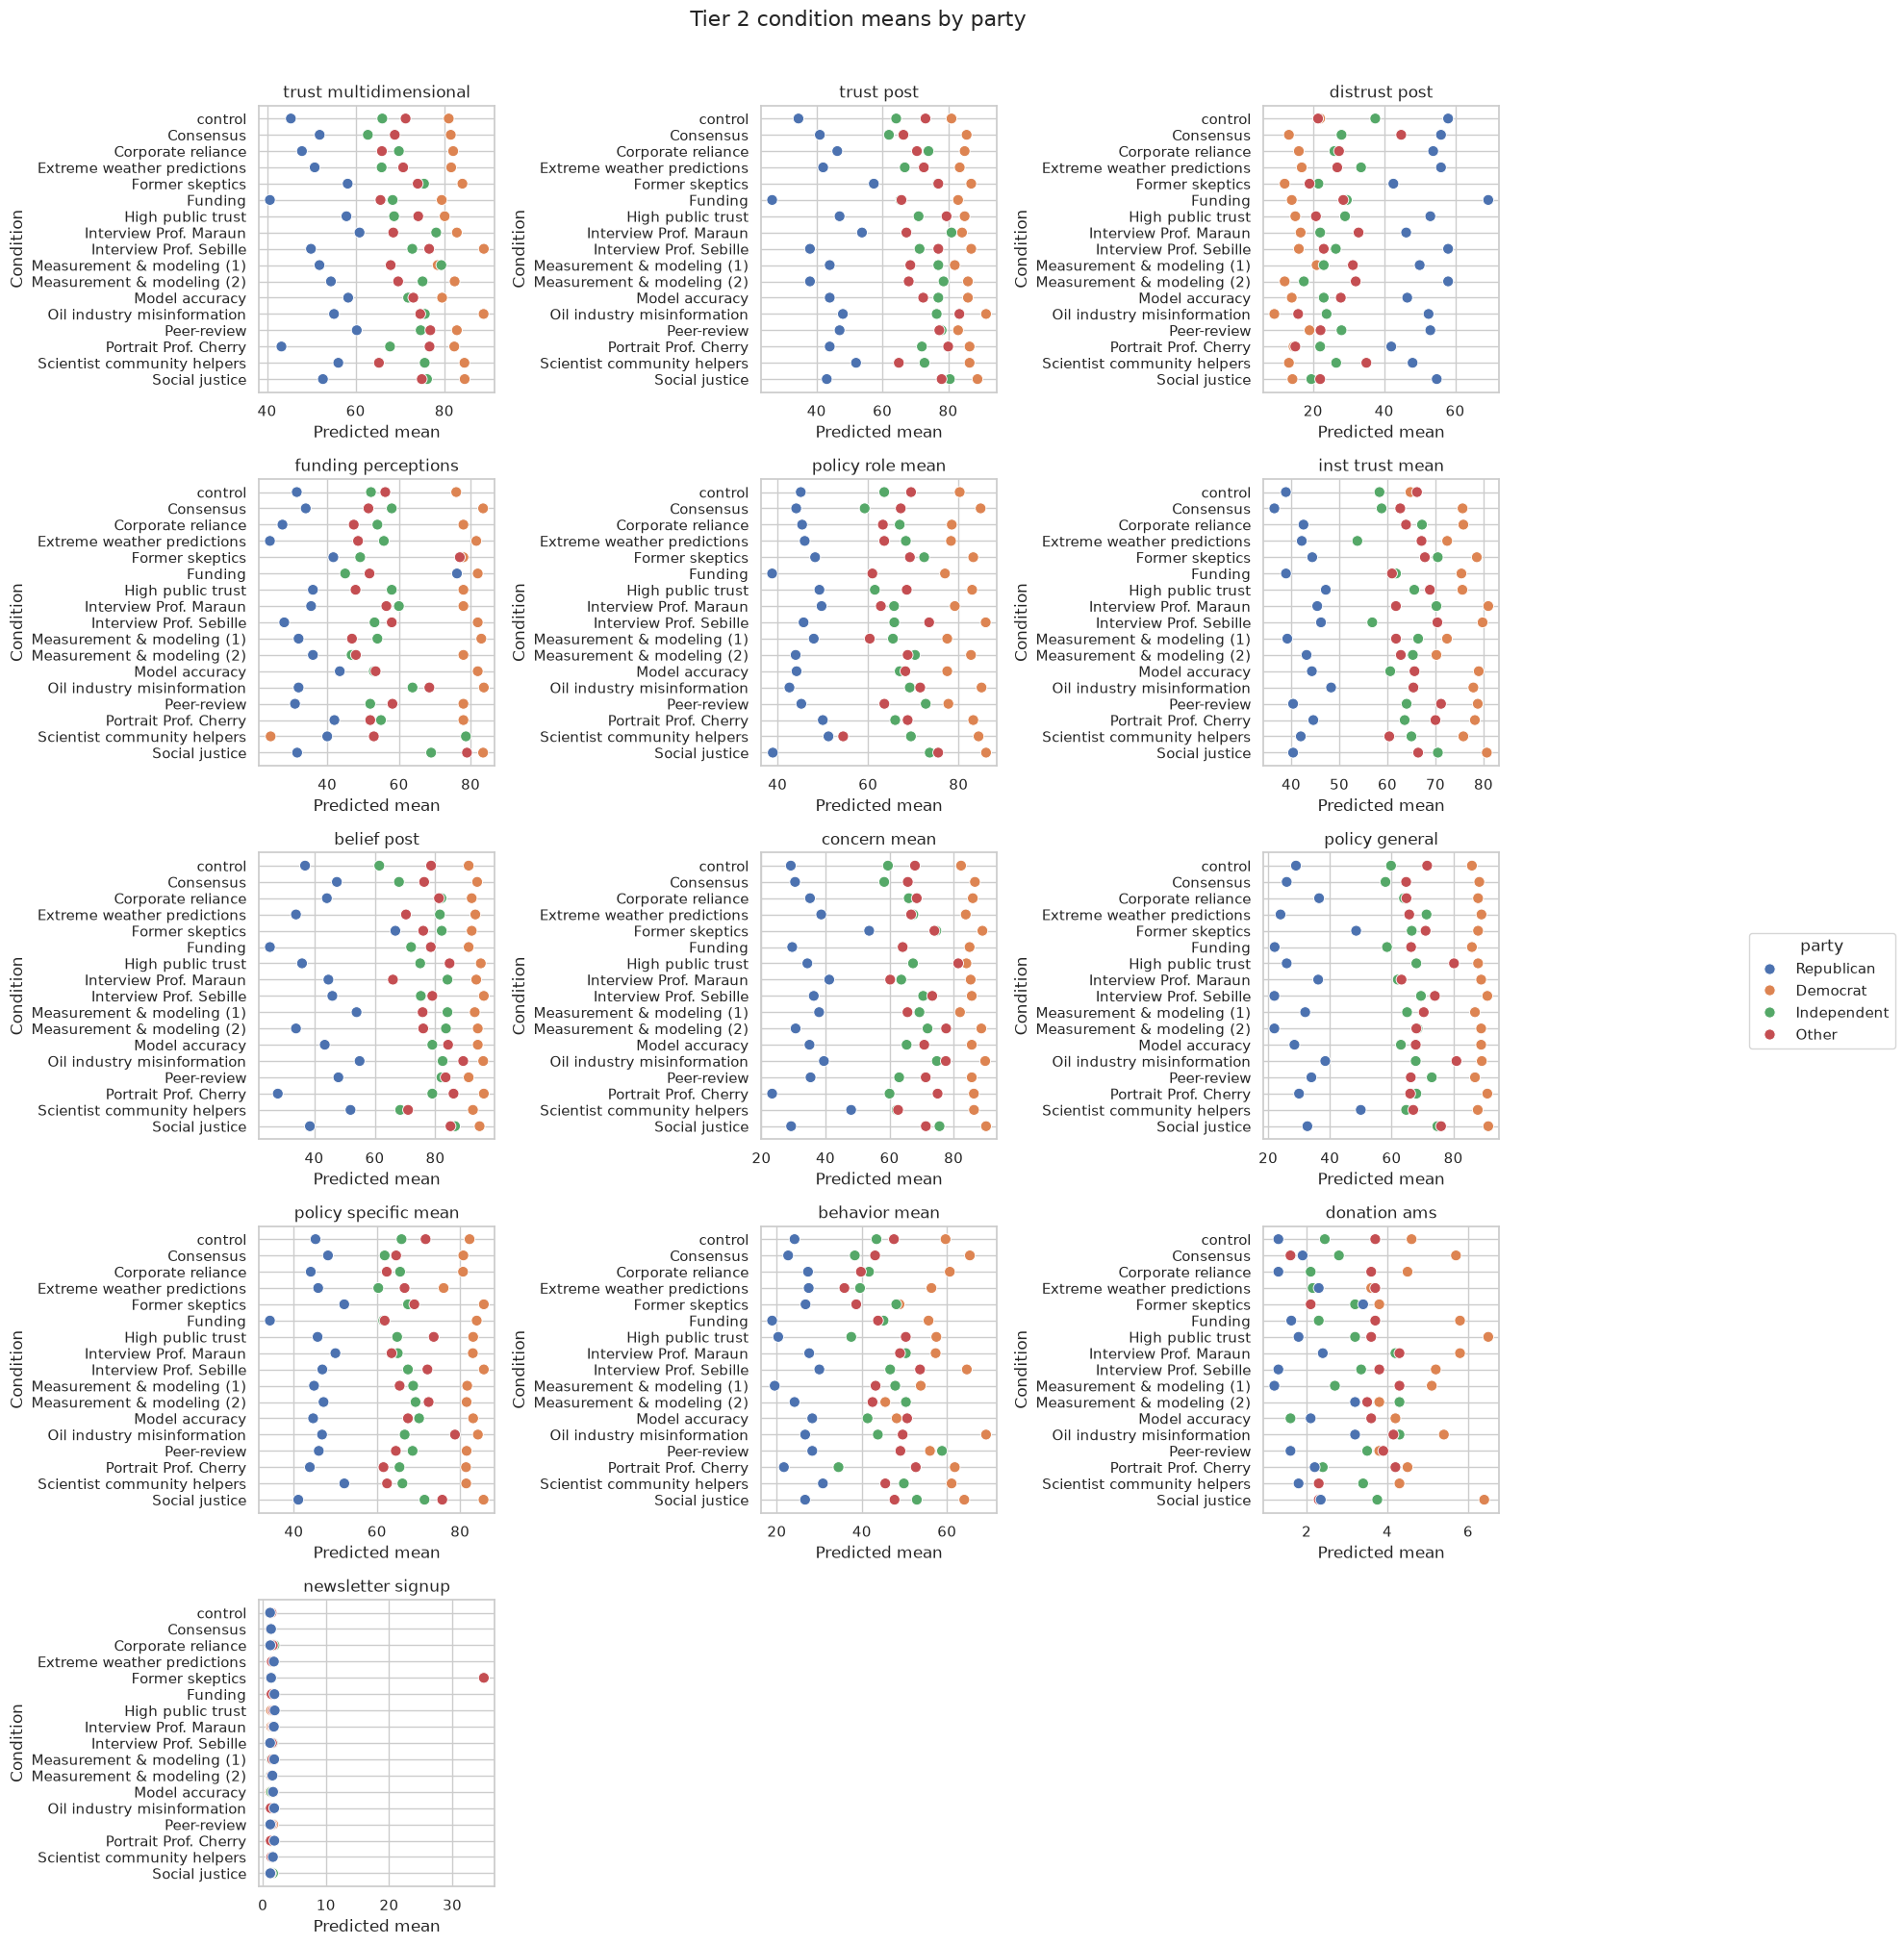

In [11]:
def plot_moderator_means(data, moderator_name, levels):
    columns = 3
    rows = math.ceil(len(OUTCOMES) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(18, 4 * rows), squeeze=False)
    legend_handles = legend_labels = None
    for axis, outcome in zip(axes.flat, OUTCOMES):
        selected = data[(data['moderator'] == moderator_name) & (data['outcome'] == outcome)]
        sns.scatterplot(
            data=selected, x='mean', y='condition', hue='moderator_level', hue_order=levels,
            s=65, palette='deep', ax=axis,
        )
        axis.set_title(outcome_label(outcome))
        axis.set_xlabel('Predicted mean')
        axis.set_ylabel('Condition')
        legend = axis.get_legend()
        if legend is not None:
            if legend_handles is None:
                legend_handles, legend_labels = axis.get_legend_handles_labels()
            legend.remove()
    for axis in axes.flat[len(OUTCOMES):]:
        axis.remove()
    pretty_name = moderator_name.replace('_', ' ')
    fig.suptitle(f'Tier 2 condition means by {pretty_name}', y=1.01, fontsize=16)
    if legend_handles:
        fig.legend(legend_handles, legend_labels, title=pretty_name, loc='center left', bbox_to_anchor=(1.01, 0.5))
    fig.tight_layout(rect=(0, 0, 0.88, 1))
    plt.show()

for moderator_name, levels in MODERATORS.items():
    plot_moderator_means(moderator, moderator_name, levels)